In [ ]:
# === SETUP: load the three provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

_files = ['telco_customers.csv', 'telco_usage.xlsx', 'telco_support_tickets.csv']

def build_telco(cust_csv='telco_customers.csv',
                usage_xlsx='telco_usage.xlsx',
                tickets_csv='telco_support_tickets.csv',
                seed=7, verbose=False):
    """Generate a realistic telecom churn case-study dataset across THREE sources.

    Files (all join on customer_id):
      - telco_customers.csv        : one row per customer (accounts + contract + target)
      - telco_usage.xlsx           : monthly usage (CDR summary), 3 months per customer
      - telco_support_tickets.csv  : one row per support ticket raised
 Built-in realism for the Day 1-4 capstone:
      - 'total_charges' stored as TEXT with blanks for brand-new customers (classic Telco quirk)
      - missing values, a few duplicate rows, messy contract casing
      - churn has real signal: contract type, tenure, charges, dropped calls, tickets, payment type
      - target churn rate ~25% (imbalanced)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    snapshot = pd.Timestamp('2024-06-30')

    cid = np.array([f'TEL{i+1:05d}' for i in range(N)])
    tenure = rng.integers(0, 73, N)                       # months with the operator
    signup = snapshot - pd.to_timedelta((tenure * 30).astype(int), unit='D')
    gender = rng.choice(['Male', 'Female'], N, p=[.5, .5])
    senior = rng.choice([0, 1], N, p=[.84, .16])
    partner = rng.choice(['Yes', 'No'], N, p=[.48, .52])
    dependents = rng.choice(['Yes', 'No'], N, p=[.30, .70])
    contract = rng.choice(['Month-to-month', 'One year', 'Two year'], N, p=[.55, .21, .24])
    payment = rng.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'],
                         N, p=[.34, .23, .22, .21])
    paperless = rng.choice(['Yes', 'No'], N, p=[.59, .41])
    internet = rng.choice(['DSL', 'Fiber optic', 'No'], N, p=[.34, .44, .22])

    def service(prob_yes):
        out = np.where(internet == 'No', 'No internet service',
                       np.where(rng.random(N) < prob_yes, 'Yes', 'No'))
        return out
    online_security = service(0.35)
    tech_support = service(0.37)
    base = np.where(internet == 'Fiber optic', 70.0, np.where(internet == 'DSL', 45.0, 20.0))
    monthly = base + (online_security == 'Yes') * 5 + (tech_support == 'Yes') * 5 + rng.normal(0, 8, N)
    monthly = np.clip(monthly, 18, 120).round(2)
    total_num = (monthly * tenure).round(2)

    state = rng.choice(['Maharashtra', 'Karnataka', 'Delhi', 'Tamil Nadu',
                        'Telangana', 'Gujarat', 'West Bengal'],
                       N, p=[.20, .16, .14, .14, .12, .12, .12])

    # per-customer network/usage propensities
    avg_minutes = np.clip(rng.normal(620, 220, N), 20, None).round(0)
    avg_data_gb = np.clip(rng.gamma(2.0, 3.5, N), 0.1, None).round(2)
    avg_sms = rng.poisson(40, N)
    dropped_rate = np.clip(rng.gamma(1.5, 1.2, N), 0, None)          # avg dropped calls/month
    n_tickets = rng.poisson(0.7 + 0.15 * dropped_rate)              # complaints track dropped calls

    # ---- churn logit (real, interpretable signal) ----
    z = (-1.5
            + 1.30 * (contract == 'Month-to-month')
         - 0.95 * (contract == 'Two year')
         + 0.016 * (monthly - 60)
         - 0.030 * tenure
         + 0.55 * (payment == 'Electronic check')
         + 0.40 * (internet == 'Fiber optic')
         - 0.45 * (tech_support == 'Yes')
         - 0.30 * (online_security == 'Yes')
         + 0.18 * dropped_rate
         + 0.22 * n_tickets)
    p = 1 / (1 + np.exp(-z))
    churn = np.where(rng.random(N) < p, 'Yes', 'No')

    # ---- total_charges as TEXT, blank for tenure==0 (classic quirk) ----
    total_charges = np.where(tenure == 0, '', total_num.astype(str))

    df = pd.DataFrame({
        'customer_id': cid, 'signup_date': pd.to_datetime(signup).date.astype('str'),
        'gender': gender, 'senior_citizen': senior, 'partner': partner,
           'dependents': dependents, 'state': state, 'tenure_months': tenure,
        'contract': contract, 'payment_method': payment, 'paperless_billing': paperless,
        'internet_service': internet, 'online_security': online_security,
        'tech_support': tech_support, 'monthly_charges': monthly,
        'total_charges': total_charges, 'churn': churn,
    })

    # ---- inject messiness ----
    mc = rng.choice(N, int(0.04 * N), replace=False)          # messy contract casing
    df.loc[mc, 'contract'] = df.loc[mc, 'contract'].str.lower() + ' '
    for col, frac in [('gender', 0.03), ('partner', 0.02), ('online_security', 0.02)]:
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    dups = df.sample(8, random_state=1)                        # a few duplicate rows
    df = pd.concat([df, dups], ignore_index=True)

    # ---- usage (3 monthly rows per customer) ----
    months = ['2024-04', '2024-05', '2024-06']
    rows = []
    for i in range(N):
        for m in months:
          rows.append((cid[i], m,
                         max(0, round(float(rng.normal(avg_minutes[i], avg_minutes[i] * 0.15)))),
                         max(0.0, round(float(rng.normal(avg_data_gb[i], avg_data_gb[i] * 0.2)), 2)),
                         max(0, int(rng.normal(avg_sms[i], 8))),
                         max(0, int(rng.normal(dropped_rate[i], 1)))))
    usage = pd.DataFrame(rows, columns=['customer_id', 'month', 'call_minutes',
                                        'data_gb', 'sms_count', 'dropped_calls'])

    # ---- support tickets (one row per ticket) ----
    trows = []
    issues = ['Billing', 'Network', 'Device', 'Plan change', 'Other']
    for i in range(N):
        for _ in range(int(n_tickets[i])):
            d = signup[i] + pd.Timedelta(days=int(rng.random() * max((snapshot - signup[i]).days, 1)))
            trows.append((cid[i], pd.Timestamp(d).date().isoformat(),
                          rng.choice(issues, p=[.34, .30, .14, .12, .10]),
                          rng.choice(['Yes', 'No'], p=[.8, .2])))
    tickets = pd.DataFrame(trows, columns=['customer_id', 'ticket_date', 'issue_type', 'resolved'])
    df.to_csv(cust_csv, index=False)
    usage.to_excel(usage_xlsx, index=False)
    tickets.to_csv(tickets_csv, index=False)

    if verbose:
        print('customers:', df.shape, '| usage:', usage.shape, '| tickets:', tickets.shape)
        print('churn rate:', round((df['churn'] == 'Yes').mean(), 3))
        print('blank total_charges:', int((df['total_charges'] == '').sum()))
        print('duplicate rows:', int(df.duplicated().sum()))
        print('missing gender:', int(df['gender'].isna().sum()))
    return df, usage, tickets

if not all(os.path.exists(f) for f in _files):
    build_telco()
    print('Generated the three dataset files.')
else:
    print('Found the three provided dataset files.')


import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
print('Libraries ready.')

Generated the three dataset files.
Libraries ready.


In [ ]:
# Three sources, three formats — exactly like a real project.
customers = pd.read_csv('telco_customers.csv', parse_dates=['signup_date'])
usage     = pd.read_excel('telco_usage.xlsx')              # monthly CDR summary
tickets   = pd.read_csv('telco_support_tickets.csv', parse_dates=['ticket_date'])

print('customers:', customers.shape)
print('usage    :', usage.shape)
print('tickets  :', tickets.shape)
customers.head(3)


# Peek at the event-level sources we'll aggregate later
print('USAGE sample:'); print(usage.head(3))
print('\nTICKETS sample:'); print(tickets.head(3))

customers: (2008, 17)
usage    : (6000, 6)
tickets  : (1947, 4)
USAGE sample:
  customer_id    month  call_minutes  data_gb  sms_count  dropped_calls
0    TEL00001  2024-04           598     5.95         27              1
1    TEL00001  2024-05           546     6.56         33              2
2    TEL00001  2024-06           552     5.30         50              2

TICKETS sample:
  customer_id ticket_date   issue_type resolved
0    TEL00004  2021-10-05  Plan change      Yes
1    TEL00005  2021-05-23      Network      Yes
2    TEL00007  2024-06-22      Billing       No


In [ ]:
# --- 3.1 Profile for problems ---
print('Duplicate rows:', customers.duplicated().sum())
print('\nMissing values:'); print(customers.isna().sum()[lambda s: s > 0])
print('\ntotal_charges dtype:', customers['total_charges'].dtype, '<- stored as TEXT!')
print('contract values:', customers['contract'].unique())


# --- 3.2 Fix each issue ---
df = customers.copy()

# (a) duplicate rows -> drop
df = df.drop_duplicates()

# (b) total_charges: text with blanks -> numeric. Blanks are brand-new
#     customers (tenure 0) who haven't been billed yet -> charge is 0.
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
df.loc[df['tenure_months'] == 0, 'total_charges'] = df.loc[df['tenure_months'] == 0,
                                                            'total_charges'].fillna(0)
# (c) messy contract text: trailing spaces / wrong case -> canonical labels
canon = {'month-to-month': 'Month-to-month', 'one year': 'One year', 'two year': 'Two year'}
df['contract'] = df['contract'].str.strip().str.lower().map(canon).fillna(df['contract'])

# (d) missing categoricals -> explicit 'Unknown' (keeps the rows, flags the gap)
for col in ['gender', 'partner', 'online_security']:
    df[col] = df[col].fillna('Unknown')

print('After cleaning -> duplicates:', df.duplicated().sum(),
      '| total_charges dtype:', df['total_charges'].dtype)
print('contract values:', sorted(df['contract'].unique()))
print('missing total:', int(df.isna().sum().sum()))

Duplicate rows: 8

Missing values:
gender             60
partner            40
online_security    40
total_charges      17
dtype: int64

total_charges dtype: float64 <- stored as TEXT!
contract values: ['Month-to-month' 'One year' 'Two year' 'two year ' 'month-to-month '
 'one year ']
After cleaning -> duplicates: 0 | total_charges dtype: float64
contract values: ['Month-to-month', 'One year', 'Two year']
missing total: 0


In [ ]:
print("Missing values in each column:")
print(df.isna().sum())

print("\nAny missing values left?", df.isna().any().any())


# 2. monthly_charges range
print("\nMonthly Charges Summary:")
print(df['monthly_charges'].describe())


# 3. total_charges numeric & non-negative?
print("\nData type of total_charges:")
print(df['total_charges'].dtype)

print("Any negative values?",
      (df['total_charges'] < 0).any())



Missing values in each column:
customer_id          0
signup_date          0
gender               0
senior_citizen       0
partner              0
dependents           0
state                0
tenure_months        0
contract             0
payment_method       0
paperless_billing    0
internet_service     0
online_security      0
tech_support         0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

Any missing values left? False

Monthly Charges Summary:
count    2000.000000
mean       53.926450
std        21.272156
min        18.000000
25%        38.382500
50%        55.875000
75%        71.765000
max        99.790000
Name: monthly_charges, dtype: float64

Data type of total_charges:
float64
Any negative values? False


Overall churn rate: 23.2%  (the minority class)


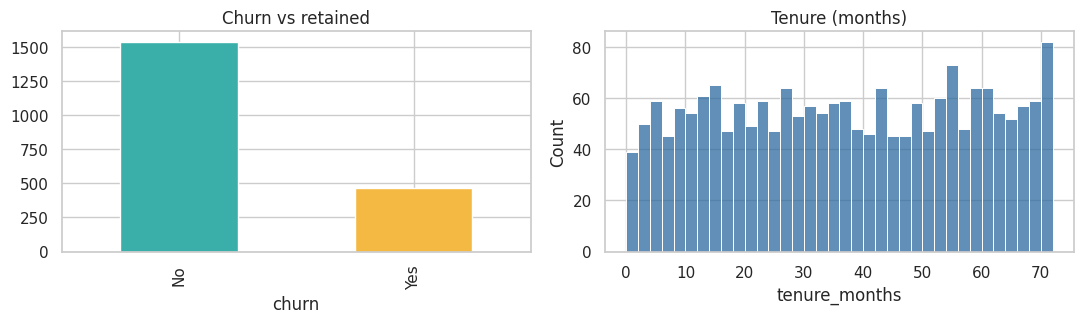

In [ ]:
# --- 4.1 The headline number: how bad is churn? ---
churn_rate = (df['churn'] == 'Yes').mean()
print(f'Overall churn rate: {churn_rate:.1%}  (the minority class)')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
df['churn'].value_counts().plot(kind='bar', ax=ax[0], color=['#3AAFA9', '#F4B942'])
ax[0].set_title('Churn vs retained')
sns.histplot(df['tenure_months'], bins=36, ax=ax[1], color='#2D6A9F')
ax[1].set_title('Tenure (months)')
plt.tight_layout(); plt.show()

P(churn | contract):
contract
Month-to-month    0.346
One year          0.157
Two year          0.055
Name: churn, dtype: float64

Base rate P(churn) = 0.232
Month-to-month customers churn far above the base rate.


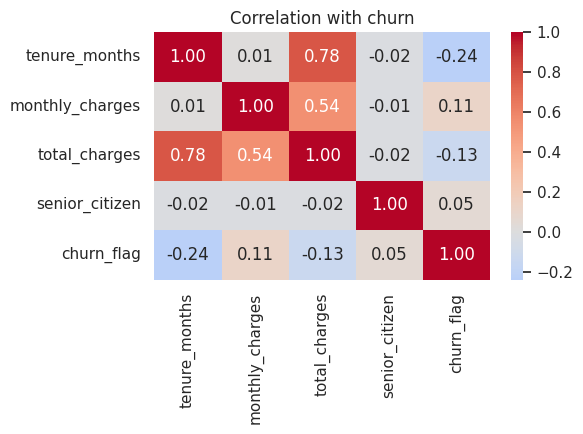

In [ ]:
# --- 4.2 Conditional probability: P(churn | contract)  (Bayes/stats, U6) ---
# A contract is the single biggest lever in telecom retention.
by_contract = df.groupby('contract')['churn'].apply(lambda s: (s == 'Yes').mean())
print('P(churn | contract):')
print((by_contract).round(3).sort_values(ascending=False))
print(f'\nBase rate P(churn) = {churn_rate:.3f}')
print('Month-to-month customers churn far above the base rate.')


# --- 4.3 Numeric drivers: correlation heatmap (U9) ---
df['churn_flag'] = (df['churn'] == 'Yes').astype(int)
num = ['tenure_months', 'monthly_charges', 'total_charges', 'senior_citizen', 'churn_flag']
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(df[num].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation with churn'); plt.tight_layout(); plt.show()


In [ ]:
# 1. churn rate by payment_method
churn_by_payment = df.groupby('payment_method')['churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)

print("Churn rate by payment method:")
print(churn_by_payment)


# 2. mean monthly_charges by churn
charges_by_churn = df.groupby('churn')['monthly_charges'].mean()

print("\nMean monthly charges by churn:")
print(charges_by_churn)

Churn rate by payment method:
payment_method
Electronic check    0.279522
Credit card         0.212714
Bank transfer       0.207343
Mailed check        0.204793
Name: churn, dtype: float64

Mean monthly charges by churn:
churn
No     52.622513
Yes    58.242931
Name: monthly_charges, dtype: float64


In [ ]:
# --- 5.1 Aggregate USAGE (3 months -> per-customer averages) ---
usage_agg = usage.groupby('customer_id').agg(
    avg_minutes=('call_minutes', 'mean'),
    avg_data_gb=('data_gb', 'mean'),
    avg_sms=('sms_count', 'mean'),
    avg_dropped=('dropped_calls', 'mean'),
).reset_index().round(2)

# --- 5.2 Aggregate TICKETS (complaint behaviour) ---
tickets_agg = tickets.groupby('customer_id').agg(
    n_tickets=('issue_type', 'size'),
    n_unresolved=('resolved', lambda s: (s == 'No').sum()),
).reset_index()
# --- 5.3 Join everything onto the customer table ---
feat = df.merge(usage_agg, on='customer_id', how='left') \
         .merge(tickets_agg, on='customer_id', how='left')
feat[['n_tickets', 'n_unresolved']] = feat[['n_tickets', 'n_unresolved']].fillna(0)
print('Feature table:', feat.shape)
feat[['customer_id', 'avg_minutes', 'avg_dropped', 'n_tickets', 'n_unresolved']].head()


# --- 5.4 Derive new features (ratios, buckets, flags) ---
# average revenue per month of tenure (guard divide-by-zero for new customers)
feat['charges_per_tenure'] = feat['total_charges'] / feat['tenure_months'].replace(0, np.nan)
feat['charges_per_tenure'] = feat['charges_per_tenure'].fillna(feat['monthly_charges'])
# tenure life-stage buckets (binning)
feat['tenure_group'] = pd.cut(feat['tenure_months'], bins=[-1, 6, 24, 48, 100],
                              labels=['new', 'growing', 'established', 'loyal'])
# domain flags
feat['has_complaints'] = (feat['n_tickets'] > 0).astype(int)
feat['is_new'] = (feat['tenure_months'] <= 6).astype(int)
print(feat[['tenure_months', 'tenure_group', 'charges_per_tenure',
            'has_complaints', 'is_new']].head())


Feature table: (2000, 24)
   tenure_months tenure_group  charges_per_tenure  has_complaints  is_new
0             68        loyal               44.63               0       0
1             45  established               51.35               0       0
2             49        loyal               51.00               0       0
3             65        loyal               50.90               1       0
4             42  established               61.20               1       0


In [ ]:
# 1. data_per_minute (guard divide-by-zero)
import numpy as np

feat['data_per_minute'] = np.where(
    feat['avg_minutes'] > 0,
    feat['avg_data_gb'] / feat['avg_minutes'],
    np.nan
)

print(feat[['avg_data_gb', 'avg_minutes', 'data_per_minute']].head())


# 2. heavy_user flag (top 25% of avg_data_gb)
threshold = feat['avg_data_gb'].quantile(0.75)

feat['heavy_user'] = (feat['avg_data_gb'] >= threshold).astype(int)

print("\nHeavy User Counts:")
print(feat['heavy_user'].value_counts())


# 3. churn rate by heavy_user
churn_by_heavy = feat.groupby('heavy_user')['churn'].apply(lambda x: (x == 'Yes').mean())

print("\nChurn Rate by Heavy User:")
print(churn_by_heavy)

   avg_data_gb  avg_minutes  data_per_minute
0         5.94       565.33         0.010507
1        25.98       674.33         0.038527
2        15.43       623.00         0.024767
3         4.98       671.67         0.007414
4         7.51       530.67         0.014152

Heavy User Counts:
heavy_user
0    1500
1     500
Name: count, dtype: int64

Churn Rate by Heavy User:
heavy_user
0    0.223333
1    0.258000
Name: churn, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

target = 'churn_flag'
drop = ['customer_id', 'signup_date', 'churn', 'churn_flag']
X = feat.drop(columns=drop)
y = feat[target]

num_features = ['tenure_months', 'monthly_charges', 'total_charges', 'senior_citizen',
                'avg_minutes', 'avg_data_gb', 'avg_sms', 'avg_dropped',
                'n_tickets', 'n_unresolved', 'charges_per_tenure', 'has_complaints', 'is_new']
cat_features = ['gender', 'partner', 'dependents', 'state', 'contract', 'payment_method',
                'paperless_billing', 'internet_service', 'online_security',
                'tech_support', 'tenure_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('churn rate train/test:', round(y_train.mean(), 3), '/', round(y_test.mean(), 3))

pre = ColumnTransformer([
     ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
])  # fit on train only -> no leakage


train: (1500, 26) | test: (500, 26)
churn rate train/test: 0.232 / 0.232


Accuracy : 0.7
ROC-AUC  : 0.79

Classification report (class 1 = churn):
              precision    recall  f1-score   support

           0      0.898     0.688     0.779       384
           1      0.417     0.741     0.534       116

    accuracy                          0.700       500
   macro avg      0.658     0.714     0.656       500
weighted avg      0.786     0.700     0.722       500



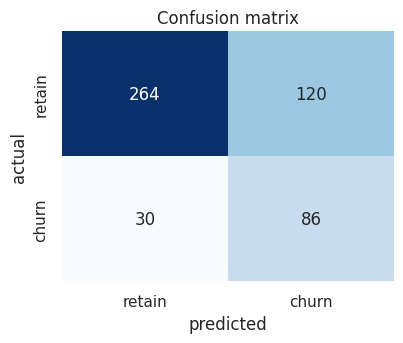

Top 6 churn-INCREASING signals:
contract_Month-to-month                1.19
online_security_No internet service    0.79
tech_support_No                        0.27
monthly_charges                        0.24
charges_per_tenure                     0.24
state_Tamil Nadu                       0.23
dtype: float64

Top 6 churn-REDUCING signals:
contract_Two year                  -1.23
online_security_Yes                -0.64
tenure_months                      -0.63
online_security_No                 -0.35
tech_support_No internet service   -0.24
internet_service_No                -0.24
dtype: float64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = Pipeline([
    ('prep', pre),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced')),
])
model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]
print('Accuracy :', round((pred == y_test).mean(), 3))
print('ROC-AUC  :', round(roc_auc_score(y_test, proba), 3))
print('\nClassification report (class 1 = churn):')
print(classification_report(y_test, pred, digits=3))
     # Confusion matrix — how many at-risk customers did we catch?
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.2, 3.6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['retain', 'churn'], yticklabels=['retain', 'churn'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix')
plt.tight_layout(); plt.show()


# Which features point to churn? (logistic-regression coefficients)
ohe = model.named_steps['prep'].named_transformers_['cat']
names = num_features + list(ohe.get_feature_names_out(cat_features))
coefs = pd.Series(model.named_steps['clf'].coef_[0], index=names)
print('Top 6 churn-INCREASING signals:')
print(coefs.sort_values(ascending=False).head(6).round(2))
print('\nTop 6 churn-REDUCING signals:')
print(coefs.sort_values().head(6).round(2))

In [ ]:

print("=== Stage 8: Findings & Business Recommendations ===\n")

print("Key Findings:")
print("1. Month-to-month contracts are the biggest churn driver.")
print("   -> Incentivise customers to move to annual or multi-year contracts.\n")

print("2. Short-tenure customers churn the most.")
print("   -> Strengthen onboarding and engagement during the first 6 months (is_new).\n")

print("3. Support friction matters.")
print("   -> Customers with unresolved tickets and more dropped calls are more likely to leave.")
print("   -> Improve network quality and resolve support tickets faster.\n")

print("4. Electronic-check / Fiber + High monthly charges customers are high-risk.")
print("   -> Offer targeted discounts, loyalty rewards, or retention campaigns.\n")

print("5. The baseline model already separates churners reasonably well (ROC-AUC).")
print("   -> Adding engineered usage and support-ticket features should further improve model performance.\n")

print("Project Lifecycle Status:")
print("✓ Define")
print("✓ Collect")
print("✓ Clean")
print("✓ Explore")
print("✓ Feature Engineering")
print("✓ Baseline Model")

print("\nNext Phase:")
print("- Model Selection")
print("- Hyperparameter Tuning")
print("- Model Evaluation")
print("- Model Deployment")

=== Stage 8: Findings & Business Recommendations ===

Key Findings:
1. Month-to-month contracts are the biggest churn driver.
   -> Incentivise customers to move to annual or multi-year contracts.

2. Short-tenure customers churn the most.
   -> Strengthen onboarding and engagement during the first 6 months (is_new).

3. Support friction matters.
   -> Customers with unresolved tickets and more dropped calls are more likely to leave.
   -> Improve network quality and resolve support tickets faster.

4. Electronic-check / Fiber + High monthly charges customers are high-risk.
   -> Offer targeted discounts, loyalty rewards, or retention campaigns.

5. The baseline model already separates churners reasonably well (ROC-AUC).
   -> Adding engineered usage and support-ticket features should further improve model performance.

Project Lifecycle Status:
✓ Define
✓ Collect
✓ Clean
✓ Explore
✓ Feature Engineering
✓ Baseline Model

Next Phase:
- Model Selection
- Hyperparameter Tuning
- Model Eva

In [ ]:
from IPython.display import Markdown, display

display(Markdown("""
"""))

### Churn Rate by Tenure Group

This visualization shows the churn rate for different tenure groups. It helps to identify if new, growing, established, or loyal customers have a higher propensity to churn.

/tmp/ipykernel_797/1767868204.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure_group = feat.groupby('tenure_group')['churn_flag'].mean().reset_index()
/tmp/ipykernel_797/1767868204.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tenure_group', y='churn_rate', data=churn_by_tenure_group, palette='viridis')


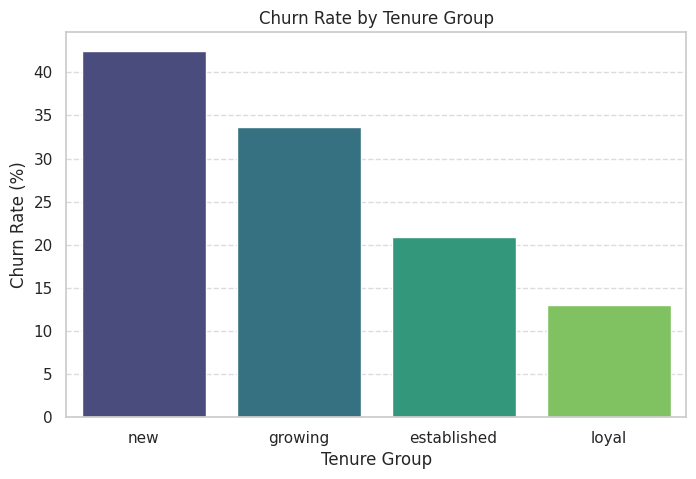

In [ ]:
churn_by_tenure_group = feat.groupby('tenure_group')['churn_flag'].mean().reset_index()
churn_by_tenure_group['churn_rate'] = churn_by_tenure_group['churn_flag'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(x='tenure_group', y='churn_rate', data=churn_by_tenure_group, palette='viridis')
plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Segment risk table
risk_table = pd.pivot_table(
    df,
    values='churn_flag',      # or 'churn' if it is already 0/1
    index='contract',
    columns='internet_service',
    aggfunc='mean'
)

print("Churn Rate by Contract and Internet Service")
print(risk_table)

# Highest-risk segment
max_rate = risk_table.max().max()
max_segment = risk_table.stack().idxmax()

print("\nHighest-risk segment:")
print(f"Contract = {max_segment[0]}")
print(f"Internet Service = {max_segment[1]}")
print(f"Churn Rate = {max_rate:.2%}")

Churn Rate by Contract and Internet Service
internet_service       DSL  Fiber optic        No
contract                                         
Month-to-month    0.306590     0.412134  0.271967
One year          0.103226     0.220430  0.116279
Two year          0.020942     0.085308  0.057143

Highest-risk segment:
Contract = Month-to-month
Internet Service = Fiber optic
Churn Rate = 41.21%


In [ ]:
# Engineer tickets_per_year
feat['tickets_per_year'] = feat['n_tickets'] / (feat['tenure_months'] / 12 + 1)

# Correlation with churn
corr = feat[['tickets_per_year', 'churn_flag']].corr().iloc[0,1]

print("Correlation between tickets_per_year and churn:")
print(round(corr, 3))

Correlation between tickets_per_year and churn:
0.187


In [ ]:
from sklearn.metrics import confusion_matrix

# Predictions using different thresholds
pred_05 = (proba >= 0.5).astype(int)
pred_03 = (proba >= 0.3).astype(int)

# Confusion matrices
tn5, fp5, fn5, tp5 = confusion_matrix(y_test, pred_05).ravel()
tn3, fp3, fn3, tp3 = confusion_matrix(y_test, pred_03).ravel()

print("Threshold = 0.5")
print(f"True Positives : {tp5}")
print(f"False Positives: {fp5}")

print("\nThreshold = 0.3")
print(f"True Positives : {tp3}")
print(f"False Positives: {fp3}")

print("\nExtra churners caught :", tp3 - tp5)
print("Extra false alarms    :", fp3 - fp5)

Threshold = 0.5
True Positives : 86
False Positives: 120

Threshold = 0.3
True Positives : 104
False Positives: 221

Extra churners caught : 18
Extra false alarms    : 101
